## Testing of the pcntoolkit implementation of ZINB likelihood

Prepare simulated dataset that is zero inflated negative binomial distributed. Because it is what I work with, it is supposed to resemble ABCD at baseline.
Apply ZINB likelihood to model the data using the PCNtoolkit.

First, import and configure and then simulate ZINB distributed data for testing

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import truncnorm, nbinom

rng = np.random.default_rng(42)

n = 12000

# ABCD-like baseline age in months
age_mean = 119.0
age_sd = 7.5
age_low = 108
age_high = 132
a = (age_low - age_mean) / age_sd
b = (age_high - age_mean) / age_sd
age_months = rng.integers(108, 133, size=n)

sex = np.where(rng.binomial(1, 0.52, size=n) == 1, "F", "M")
site = np.array([f"site{i}" for i in rng.integers(0, 21, size=n)])

age_z = (age_months - age_months.mean()) / age_months.std()

# NB mean model
eta_mu = 1.2 + 0.35 * age_z + 0.25 * (sex == "F") + 0.08 * (np.array([int(s[4:]) for s in site]) - np.array([int(s[4:]) for s in site]).mean()) / np.array([int(s[4:]) for s in site]).std()
mu = np.exp(eta_mu)
mu = np.clip(mu, 0.1, 16.0)

# Zero inflation model
eta_psi = 0.4 + 0.2 * age_z + 0.1 * (sex == "F") + 0.10 * (np.array([int(s[4:]) for s in site]) == 0)
psi = 1 / (1 + np.exp(-eta_psi))
psi = np.clip(psi, 0.02, 0.30)

# NB dispersion
alpha = 0.40
r = 1.0 / alpha
p = r / (r + mu)

struct_zero = rng.binomial(1, psi, size=n)
y_nb = nbinom.rvs(r, p, random_state=rng)
y = np.where(struct_zero == 1, 0, y_nb)

df = pd.DataFrame({
    "age": age_months,
    "sex": sex,
    "site": site,
    "age_z": age_z,
    "mu": mu,
    "psi": psi,
    "alpha": alpha,
    "y": y,
    "struct_zero": struct_zero,
})

df.to_csv("zinb_abcd_like_simulated_data.csv", index=False)

summary = pd.Series({
    "n": n,
    "age_mean": age_months.mean(),
    "age_sd": age_months.std(),
    "sex_male_prop": (sex == "M").mean(),
    "mean_mu": mu.mean(),
    "mean_psi": psi.mean(),
    "zero_rate": (y == 0).mean(),
    "mean_y": y.mean(),
    "var_y": y.var(),
    "max_y": y.max()
})
summary.to_csv("zinb_abcd_like_summary.csv")
summary

n                12000.000000
age_mean           119.937250
age_sd               7.170238
sex_male_prop        0.484417
mean_mu              4.058428
mean_psi             0.300000
zero_rate            0.381167
mean_y               2.800583
var_y               12.802316
max_y               33.000000
dtype: float64

## Plot simulated data

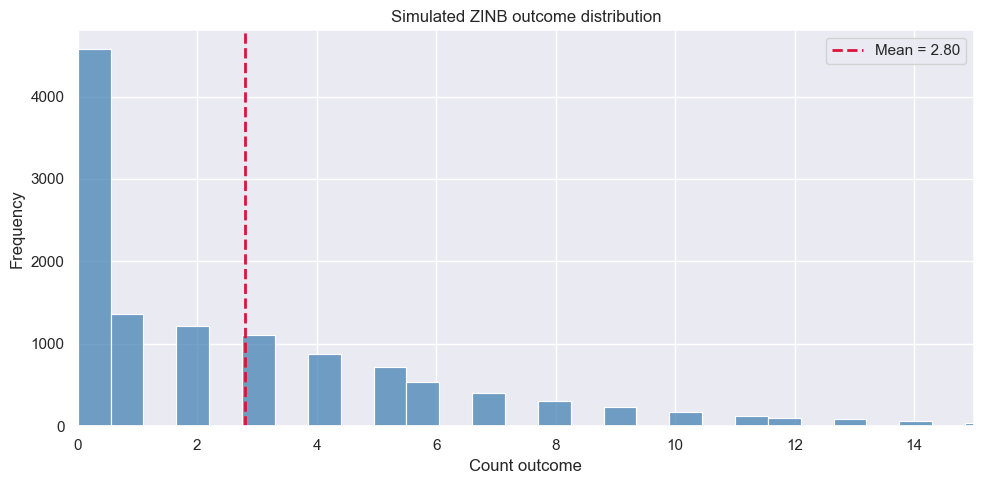

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["y"], bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Simulated ZINB outcome distribution")
ax.set_xlabel("Count outcome")
ax.set_ylabel("Frequency")
ax.set_xlim(0, np.quantile(df["y"], 0.99))
ax.axvline(df["y"].mean(), color="crimson", linestyle="--", linewidth=2, label=f"Mean = {df['y'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## Set up pcntoolkit

In [31]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    ZeroInflatedNegativeBinomialLikelihood,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Use simulated ZINB distributed data to test likelihood implementation

       age sex    site     age_z        mu  psi  alpha   y  struct_zero
0      110   F  site10 -1.385902  2.624189  0.3    0.4   0            1
1      127   F   site2  0.985009  5.415337  0.3    0.4   5            0
2      124   M   site7  0.566613  3.890913  0.3    0.4   9            0
3      118   F  site16 -0.270179  4.196671  0.3    0.4   4            0
4      118   F  site12 -0.270179  3.981321  0.3    0.4  11            0
...    ...  ..     ...       ...       ...  ...    ...  ..          ...
11995  128   F  site16  1.124475  6.837488  0.3    0.4   8            0
11996  109   M  site10 -1.525368  1.946356  0.3    0.4   1            0
11997  129   M   site6  1.263940  4.901487  0.3    0.4   8            0
11998  116   M  site11 -0.549110  2.775466  0.3    0.4   0            1
11999  128   F   site9  1.124475  6.235347  0.3    0.4   1            0

[12000 rows x 9 columns]
<xarray.DataArray 'batch_effects' (observations: 12000, batch_effect_dims: 2)> Size: 576kB
array([['F', 'site1

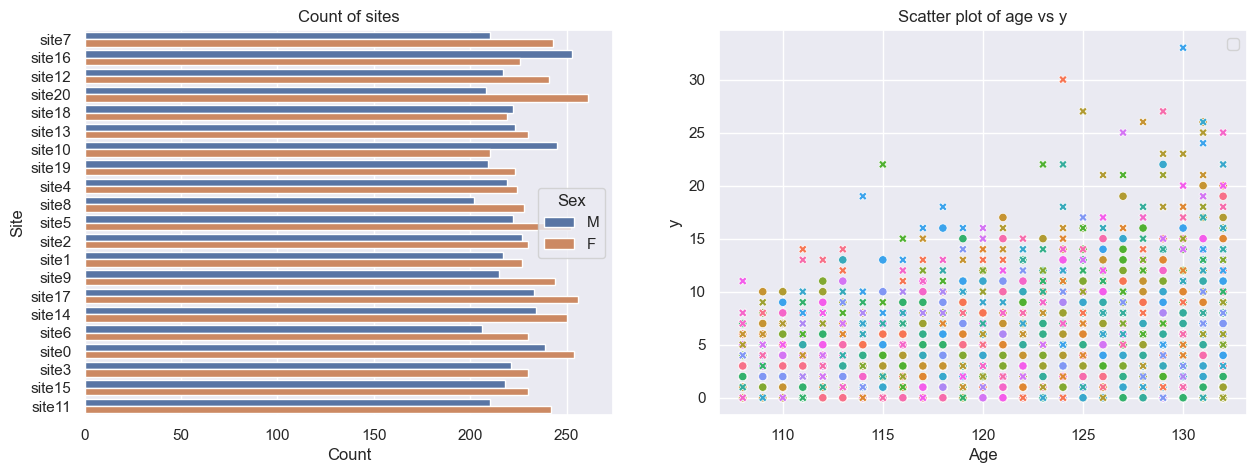

In [32]:
from sklearn.model_selection import train_test_split
from pcntoolkit import NormData

covariate_cols = ["age"]
batch_effects = ["sex", "site"]
response_variables = ["y"]

# Make sure categories / numeric types are sensible
df = df.copy()
df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(str)
df["site"] = df["site"].astype(str)
df["y"] = df["y"].astype(int)

print(df)

# Build NormData
norm_data = NormData.from_dataframe(
    name="ZINB_CBCL_sim",
    dataframe=df,
    covariates=covariate_cols,
    batch_effects=batch_effects,
    response_vars=response_variables,
    remove_outliers=True,
    z_threshold=10,
)

norm_data.data_vars

# Split into train and test
train, test = norm_data.train_test_split()

train, test

# Visualize the data
features_to_model = response_variables
feature_to_plot = features_to_model[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Site")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

print(norm_data.batch_effects)


## Set up modeling parameters for ZINB
I am working off of specifications of paranmeters for different likelihoods and 

In [33]:
mu = make_prior(
    # Mu is linear because we want to allow the mean to vary as a function of the covariates.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 10.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 5.0)),
    # The intercept is random, because we expect the intercept to vary between sites and sexes.
    intercept=make_prior(
        random=True,
        # Mu is the mean of the intercept, which is normally distributed with a mean of 0 and a standard deviation of 1.
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        # Sigma is the scale at which the intercepts vary. It is a positive parameter, so we have to map it to the positive domain.
        sigma=make_prior(dist_name="Gamma", dist_params=(1.0, 1.0)),
    ),
    # Implemented softplus mapping to mu because sampler was having issues with negative values for mu (why are they there?)
    mapping="softplus",
    # We use a B-spline basis function to allow for non-linearity in the mean.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
alpha = make_prior(
    # Sigma is also linear, because we want to allow the standard deviation to vary as a function of the covariates: heteroskedasticity.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 2.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    # The intercept is not random, because we assume the intercept of the variance to be the same for all sites and sexes.
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    # We use a B-spline basis function to allow for non-linearity in the standard deviation.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    # We use a softplus mapping to ensure that sigma is strictly positive.
    mapping="softplus",
    # We scale the softplus mapping by a factor of 3, to avoid spikes in the resulting density.
    # The parameters (a, b, c) provided to a mapping f are used as: f_abc(x) = f((x - a) / b) * b + c
    # This basically provides an affine transformation of the softplus function.
    # a -> horizontal shift
    # b -> scaling
    # c -> vertical shift
    # You can leave c out, and it will default to 0.
    mapping_params=(0.0, 2.0),
)

psi = make_prior(
    # Psi should also be linear because we want to allow the zero-inflation probability to vary as a function of the covariates.
    linear=True,
    # The slope coefficients can be assumed to be normally distributed, with a mean of 0 and a standard deviation of 1.
    slope=make_prior(dist_name="Normal", dist_params=(0,1)),
    # The intercept is not random, because we assume the intercept of the zero-inflation probability to be the same for all sites and sexes.
    intercept=make_prior(dist_name="Normal", dist_params=(0,1)),
    # We use B-spline basis function as in the others
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    # Leaving at softplus ensures that probability is strictly positive and it is the framework already in place
    mapping="softplus"
)

# Set the likelihood with the priors we just created.
likelihood = ZeroInflatedNegativeBinomialLikelihood(mu, alpha, psi)

template_hbr = HBR(
    name="template",
    # The number of cores to use for sampling.
    cores=16,
    # Whether to show a progress bar during the model fitting.
    progressbar=True,
    # The number of draws to sample from the posterior per chain.
    draws=1500,
    # The number of tuning steps to run.
    tune=500,
    # The number of MCMC chains to run.
    chains=4,
    # The sampler to use for the model.
    nuts_sampler="nutpie",
    # The likelihood function to use for the model.
    likelihood=likelihood,
)

In [34]:
model = NormativeModel(
    # The regression model to use for the normative model.
    template_regression_model=template_hbr,
    # Whether to save the model after fitting.
    savemodel=True,
    # Whether to evaluate the model after fitting.
    evaluate_model=True,
    # Whether to save the results after evaluation.
    saveresults=True,
    # Whether to save the plots after fitting.
    saveplots=False,
    # The directory to save the model, results, and plots.
    save_dir="/Users/lenobl/PCNtoolkit_dir/output/ZINB_testing",
    # The scaler to use for the input data. Can be either one of "standardize", "minmax", "robminmax", "none"
    inscaler="standardize",
    # The scaler to use for the output data. Can be either one of "standardize", "minmax", "robminmax", "none"
    outscaler="standardize",
)

model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,35,0.14,31
,2000,25,0.17,63
,2000,19,0.14,63
,2000,20,0.13,31


mu: <class 'numpy.ndarray'> (9600, 6000)
alpha: <class 'numpy.ndarray'> (9600, 6000)
psi: <class 'numpy.ndarray'> (9600, 6000)
Z: <class 'numpy.ndarray'> (9600, 1)
mu: <class 'numpy.ndarray'> (9600, 6000)
alpha: <class 'numpy.ndarray'> (9600, 6000)
psi: <class 'numpy.ndarray'> (9600, 6000)
Z: <class 'numpy.ndarray'> (9600, 1)
mu: <class 'numpy.ndarray'> (9600, 6000)
alpha: <class 'numpy.ndarray'> (9600, 6000)
psi: <class 'numpy.ndarray'> (9600, 6000)
Z: <class 'numpy.ndarray'> (9600, 1)
mu: <class 'numpy.ndarray'> (9600, 6000)
alpha: <class 'numpy.ndarray'> (9600, 6000)
psi: <class 'numpy.ndarray'> (9600, 6000)
Z: <class 'numpy.ndarray'> (9600, 1)
y_nb: (2394328,)
mu: <class 'numpy.ndarray'> (9600, 6000)
alpha: <class 'numpy.ndarray'> (9600, 6000)
psi: <class 'numpy.ndarray'> (9600, 6000)
Z: <class 'numpy.ndarray'> (9600, 1)
y_nb: (55894349,)


/opt/homebrew/anaconda3/envs/ptk-dev/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9600.
  res = hypotest_fun_out(*samples, **kwds)


mu: <class 'numpy.ndarray'> (2400, 6000)
alpha: <class 'numpy.ndarray'> (2400, 6000)
psi: <class 'numpy.ndarray'> (2400, 6000)
Z: <class 'numpy.ndarray'> (2400, 1)
mu: <class 'numpy.ndarray'> (2400, 6000)
alpha: <class 'numpy.ndarray'> (2400, 6000)
psi: <class 'numpy.ndarray'> (2400, 6000)
Z: <class 'numpy.ndarray'> (2400, 1)
mu: <class 'numpy.ndarray'> (2400, 6000)
alpha: <class 'numpy.ndarray'> (2400, 6000)
psi: <class 'numpy.ndarray'> (2400, 6000)
Z: <class 'numpy.ndarray'> (2400, 1)
mu: <class 'numpy.ndarray'> (2400, 6000)
alpha: <class 'numpy.ndarray'> (2400, 6000)
psi: <class 'numpy.ndarray'> (2400, 6000)
Z: <class 'numpy.ndarray'> (2400, 1)
y_nb: (651961,)
mu: <class 'numpy.ndarray'> (2400, 6000)
alpha: <class 'numpy.ndarray'> (2400, 6000)
psi: <class 'numpy.ndarray'> (2400, 6000)
Z: <class 'numpy.ndarray'> (2400, 1)
y_nb: (14002534,)


<xarray.NormData> Size: 365kB
Dimensions:            (observations: 2400, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 19kB 5136 10282 5732 ... 7447 11128
  * response_vars      (response_vars) <U1 4B 'y'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 19kB 5136 10282 5732 ... 7447 11128
    Y                  (observations, response_vars) float64 19kB 5.0 ... 5.0
    X                  (observations, covariates) float64 19kB 119.0 ... 131.0
    batch_effects      (observations, batch_effect_dims) <U6 115kB 'M' ... 's...
    Z                  (observations, response_vars) float64 19kB 0.1747 ... ...
    centiles           (centile, observations, response_vars) float64 96kB 2....
    baseline_logp      (observations, response_vars) float64 19kB -1.108 ... ...
    logp               (observations, response_vars) float64 19kB -0.08533 .....
    Yhat               (observations, response_vars) float64 19kB 3.747 ... 6...
    statistics         (response_vars, statistic) float64 104B 0.07535 ... 0....
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           ZINB_CBCL_sim_test
    unique_batch_effects:           {np.str_('sex'): ['F', 'M'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 108.0, 'max': 13...
    batch_effect_covariate_ranges:  {np.str_('sex'): {'F': {np.str_('age'): {...

## Plot centiles

## debugging

In [38]:
print(train.batch_effects[:5])
print(train.batch_effects.shape)

print(test.batch_effects[:5])
print(test.batch_effects.shape)

print(model.batch_effects_maps)

<xarray.DataArray 'batch_effects' (observations: 5, batch_effect_dims: 2)> Size: 240B
array([['F', 'site4'],
       ['M', 'site10'],
       ['F', 'site20'],
       ['F', 'site8'],
       ['F', 'site3']], dtype='<U6')
Coordinates:
  * observations       (observations) int64 40B 274 793 3870 5065 8800
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
(9600, 2)
<xarray.DataArray 'batch_effects' (observations: 5, batch_effect_dims: 2)> Size: 240B
array([['M', 'site12'],
       ['F', 'site12'],
       ['M', 'site19'],
       ['M', 'site10'],
       ['F', 'site8']], dtype='<U6')
Coordinates:
  * observations       (observations) int64 40B 5136 10282 5732 3846 11914
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
(2400, 2)
{np.str_('sex'): {'F': 0, 'M': 1}, np.str_('site'): {'site10': 0, 'site2': 1, 'site7': 2, 'site16': 3, 'site12': 4, 'site20': 5, 'site18': 6, 'site13': 7, 'site19': 8, 'site4': 9, 'site8': 10, 'site5': 11, 'site1': 12, 'site9': 13, 'site17': 14

In [36]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=train,  # Scatter this data along with the centiles
    batch_effects={"site": "site10", "sex": ["M"]},  # Highlight these groups
    show_other_data=True,  # scatter data not in those groups as smaller black circles
    harmonize_data=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
)

KeyError: np.str_('s')